In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
import sklearn as skl
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [5]:
df = pd.read_csv('2.csv')

In [6]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(918, 12)
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [7]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [8]:
number = []
bl = []
for i in df.columns:
    if len(df[i].value_counts()) <= 4:
        bl.append(i)
    else:
        number.append(i)
print(number)
print(bl)

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']


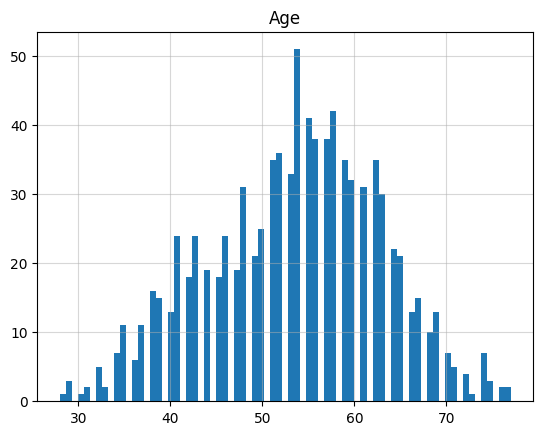

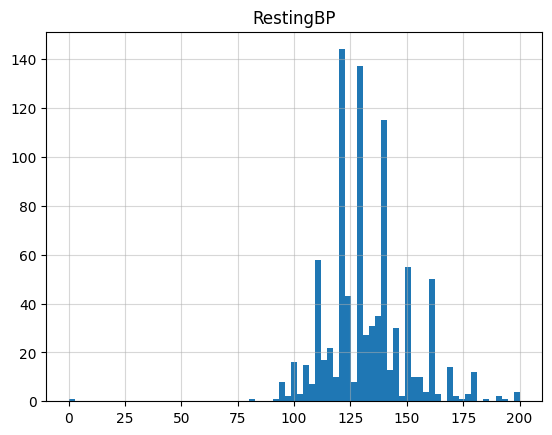

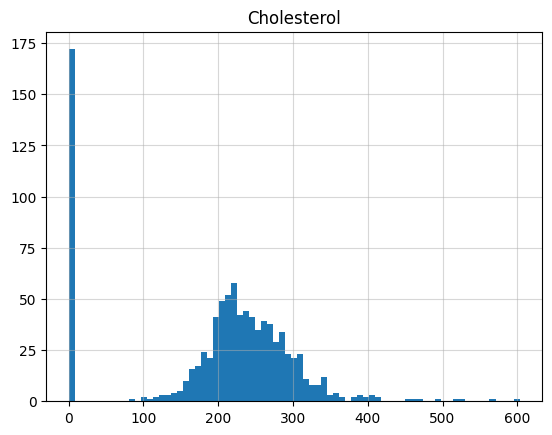

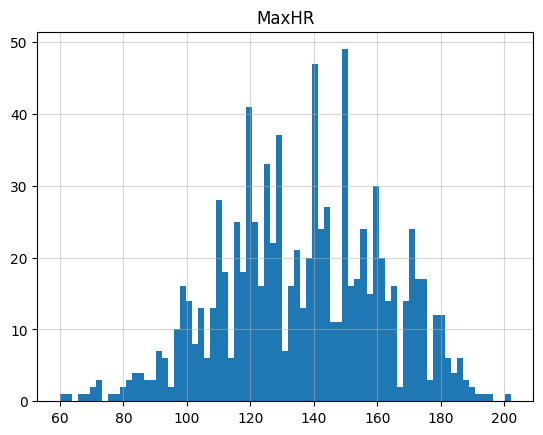

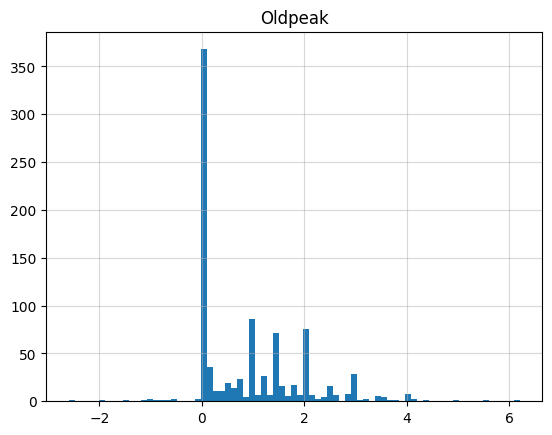

In [9]:
for i in number:
  plt.hist(df[i], bins=75)
  plt.title(i)
  plt.grid(alpha=0.5)
  plt.show()

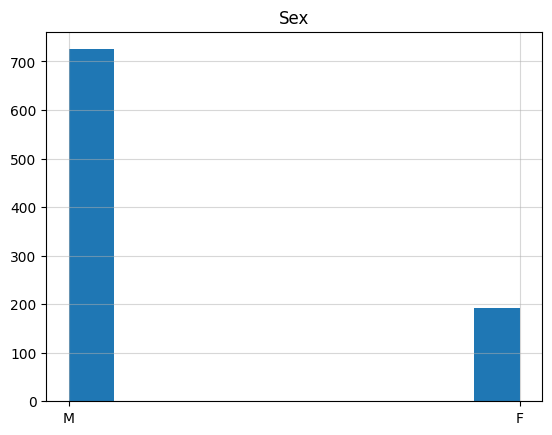

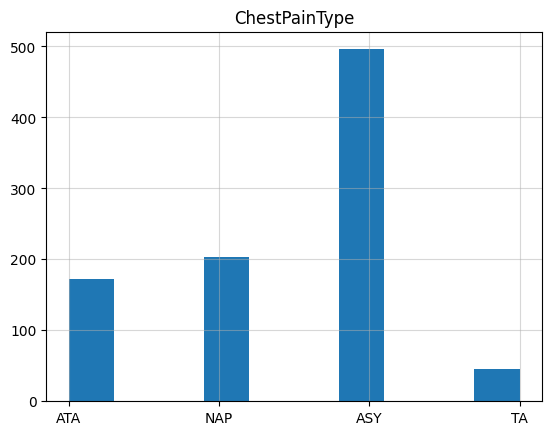

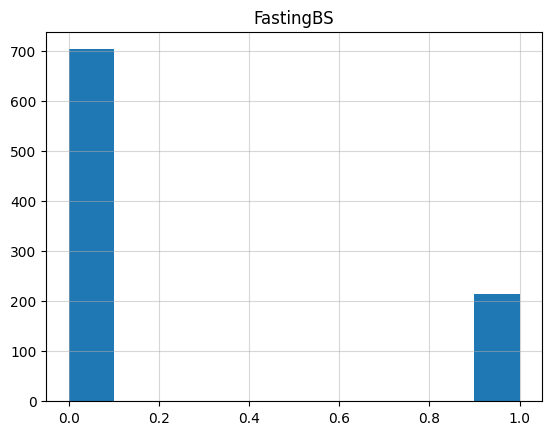

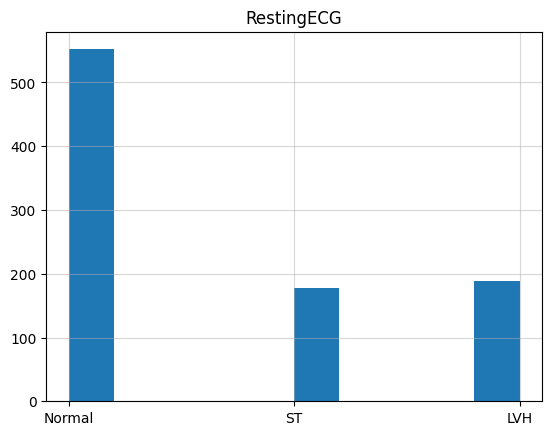

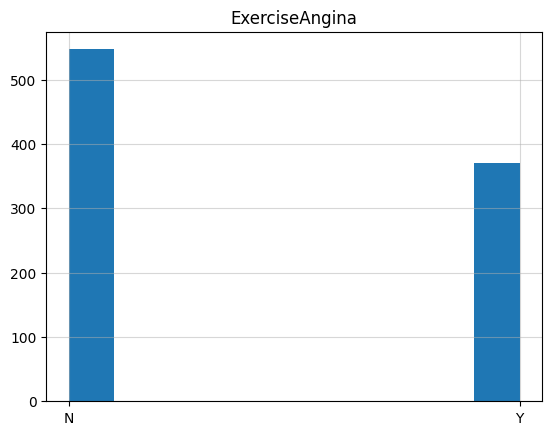

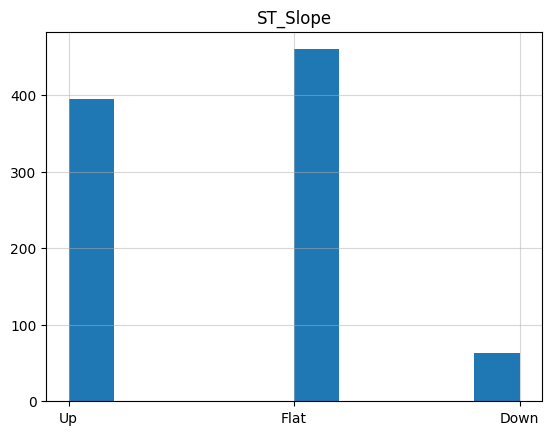

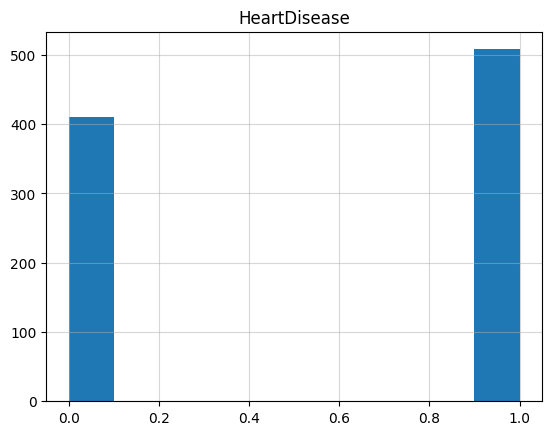

In [10]:
for i in bl:
  plt.hist(df[i])
  plt.title(i)
  plt.grid(alpha=0.5)
  plt.show()

In [11]:
outres = df[df['RestingBP'] > 0]
resmed = float(outres['RestingBP'].median())

outchol = df[df['Cholesterol'] > 0]
chomed = float(outchol['Cholesterol'].median())

df['RestingBP'] = df['RestingBP'].replace(0, resmed)
df['Chol_Missing'] = (df['Cholesterol'] == 0).astype(int)
df['Cholesterol'] = df['Cholesterol'].replace(0, chomed)

In [12]:
df = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype=int, drop_first=True)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[number] = scaler.fit_transform(df[number])

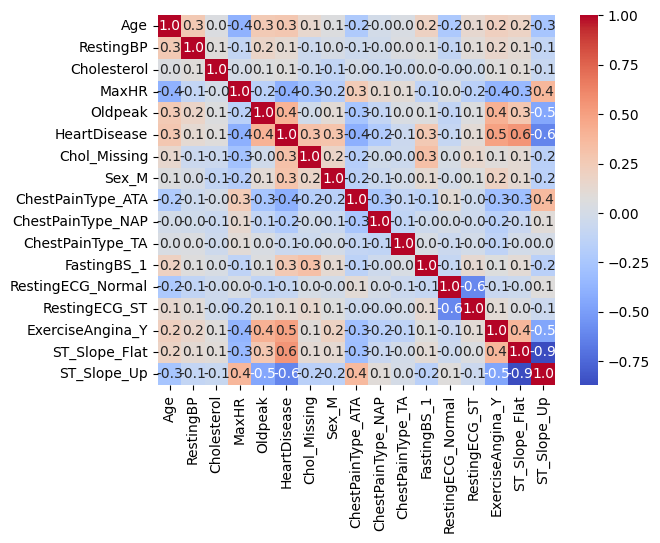

In [13]:
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.show()

In [14]:
X = df.drop(columns=['HeartDisease'])
Y = df['HeartDisease']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

params = {
    'C': [0.01, 0.1, 0.5, 1, 5, 10],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'solver': ['saga'],
    'max_iter': [5000],
    'class_weight' : ['balanced', None]
}

lrsearch = GridSearchCV(LogisticRegression(max_iter=5000), params, cv=5,
    n_jobs=-1,
    scoring='f1')


lrsearch.fit(X_train, Y_train)

logregbest = lrsearch.best_params_
print(logregbest)
print(f"Лучший f1-score на CV: {lrsearch.best_score_:.4f}")

{'C': 0.5, 'class_weight': None, 'l1_ratio': 0.5, 'max_iter': 5000, 'solver': 'saga'}
Лучший f1-score на CV: 0.8841


In [15]:
X = df.drop(columns=['HeartDisease'])
Y = df['HeartDisease']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

knnsearch = GridSearchCV(KNeighborsClassifier(), params, cv=5,
    n_jobs=-1,
    scoring='f1')


knnsearch.fit(X_train, Y_train)
knnbest = knnsearch.best_params_
print(knnbest)
print(f"Лучший f1-score на CV: {knnsearch.best_score_:.4f}")

{'metric': 'manhattan', 'n_neighbors': 21, 'p': 1, 'weights': 'distance'}
Лучший f1-score на CV: 0.8806


In [18]:
X = df.drop(columns=['HeartDisease'])
Y = df['HeartDisease']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight' : ['balanced']
}

destsearch = GridSearchCV(DecisionTreeClassifier(), params, cv=5,
    n_jobs=-1,
    scoring='f1')


destsearch.fit(X_train, Y_train)

destree_best = destsearch.best_params_
print(destree_best)
print(f"Лучший f1-score на CV: {destsearch.best_score_:.4f}")

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 20}
Лучший f1-score на CV: 0.8694


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split


X = df.drop(columns=['HeartDisease'])
Y = df['HeartDisease']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


rf_params = {
    'n_estimators': [50],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}


rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

rf_search.fit(X_train, Y_train)

rf_best_params = rf_search.best_params_
print("\nЛучшие параметры для RandomForestClassifier:")
print(rf_best_params)
print(f"Лучший F1-score на CV: {rf_search.best_score_:.4f}")


Лучшие параметры для RandomForestClassifier:
{'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Лучший F1-score на CV: 0.8880


In [20]:
from catboost import CatBoostClassifier
X = df.drop(columns=['HeartDisease'])
Y = df['HeartDisease']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
cb_params = {
    'iterations': [145, 300],        
    'depth': [4, 6, 8],            
    'learning_rate': [0.03, 0.1],    
    'l2_leaf_reg': [3, 5, 7],         
    'border_count': [128],       
    'thread_count': [-1]         
}

cb_model = CatBoostClassifier(
    random_seed=42,
    task_type='CPU',
    verbose=False
)

cb_search = GridSearchCV(
    cb_model,
    cb_params,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

cb_search.fit(X_train, Y_train)

print("\nЛучшие параметры для CatBoostClassifier:")
print(cb_search.best_params_)
print(f"Лучший F1-score на CV: {cb_search.best_score_:.4f}")


Лучшие параметры для CatBoostClassifier:
{'border_count': 128, 'depth': 8, 'iterations': 145, 'l2_leaf_reg': 5, 'learning_rate': 0.1, 'thread_count': -1}
Лучший F1-score на CV: 0.8971


In [21]:
acc = 0
pre = 0
rec = 0
f1 = 0
for i in range(10):
    cb_model = CatBoostClassifier(**{'thread_count': -1, 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 100, 'depth': 4, 'border_count': 128, 'verbose' : False}, random_state=i)
    cb_model.fit(X_train, Y_train)
    pred = cb_model.predict(X_test)
    acc += accuracy_score(Y_test, pred)
    pre += precision_score(Y_test, pred)
    rec += recall_score(Y_test, pred)
    f1 += f1_score(Y_test, pred)
    print(acc/(i+1))
    print(pre/(i+1))
    print(rec/(i+1))
    print(f1/(i+1))
    print()

0.8913043478260869
0.8942307692307693
0.9117647058823529
0.9029126213592233

0.8913043478260869
0.8980957767722474
0.9068627450980392
0.9024367028364744

0.8931159420289855
0.8997013916345727
0.9084967320261438
0.9040634929478935

0.8940217391304348
0.9005041990657354
0.9093137254901961
0.904876888003603

0.8934782608695653
0.8992495130987421
0.9098039215686274
0.9044840346747272

0.8940217391304347
0.8998600311421557
0.9101307189542484
0.9049562077573946

0.8944099378881987
0.9002961154588797
0.9103641456582634
0.9052934742450142

0.8940217391304347
0.8995379471803658
0.9105392156862746
0.9049958676342903

0.893719806763285
0.8998071513062946
0.9095860566448803
0.9046586361542275

0.8940217391304348
0.9001176983115876
0.9098039215686275
0.904924479855878



In [22]:
model = CatBoostClassifier(**{'thread_count': -1, 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 100, 'depth': 4, 'border_count': 128, 'verbose' : False}, random_state=42)
model.fit(X, Y)
import joblib
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(model, 'catboost.cbm')


['catboost.cbm']

In [23]:
healthy_person = [74, 'F', 'NAP', 125, 215, 0, 'Normal', 150, 'N', 0.0, 'Up']
sick_person = [26, 'M', 'ASY', 140, 290, 1, 'ST', 130, 'Y', 1.8, 'Flat']
columns = ['Age','Sex','ChestPainType','RestingBP','Cholesterol','FastingBS','RestingECG','MaxHR','ExerciseAngina','Oldpeak','ST_Slope']
dt = pd.DataFrame([healthy_person], columns=columns)
dt['Chol_Missing'] = 0
expected_columns = model.feature_names_
dt = pd.get_dummies(dt, columns=['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype=int)
dt = dt.reindex(columns=expected_columns, fill_value=0)
dt[number] = scaler.transform(dt[number])
pred = model.predict(dt)
round(model.predict_proba(dt)[0][1].item()*100, 2)

4.19